
LOADING FLIGHT DATA
Maneuver 1: 1562 data points, time range: 528.85 to 553.85 seconds
Maneuver 2: 3430 data points, time range: 989.32 to 1039.31 seconds

MODAL COORDINATE TRANSFORMATION

Transforming Maneuver 1 to modal coordinates...
  Longitudinal modal coordinates shape: (1562, 4)
  Lateral modal coordinates shape: (1562, 4)

Transforming Maneuver 2 to modal coordinates...
  Longitudinal modal coordinates shape: (3430, 4)
  Lateral modal coordinates shape: (3430, 4)

MODE IDENTIFICATION

Longitudinal Eigenvalues:
  Index 0: λ = -2.221854 + 2.906568j, |λ| = 3.658520 rad/s
  Index 1: λ = -2.221854 + -2.906568j, |λ| = 3.658520 rad/s
  Index 2: λ = -0.004346 + 0.180481j, |λ| = 0.180533 rad/s
  Index 3: λ = -0.004346 + -0.180481j, |λ| = 0.180533 rad/s

Identified Modes:
  Phugoid Mode: indices 2 and 3
    λ = -0.004346 ± 0.180481j
    Natural frequency: 0.180533 rad/s

  Short Period Mode: indices 0 and 1
    λ = -2.221854 ± 2.906568j
    Natural frequency: 3.658520 rad/s

Lateral Eig

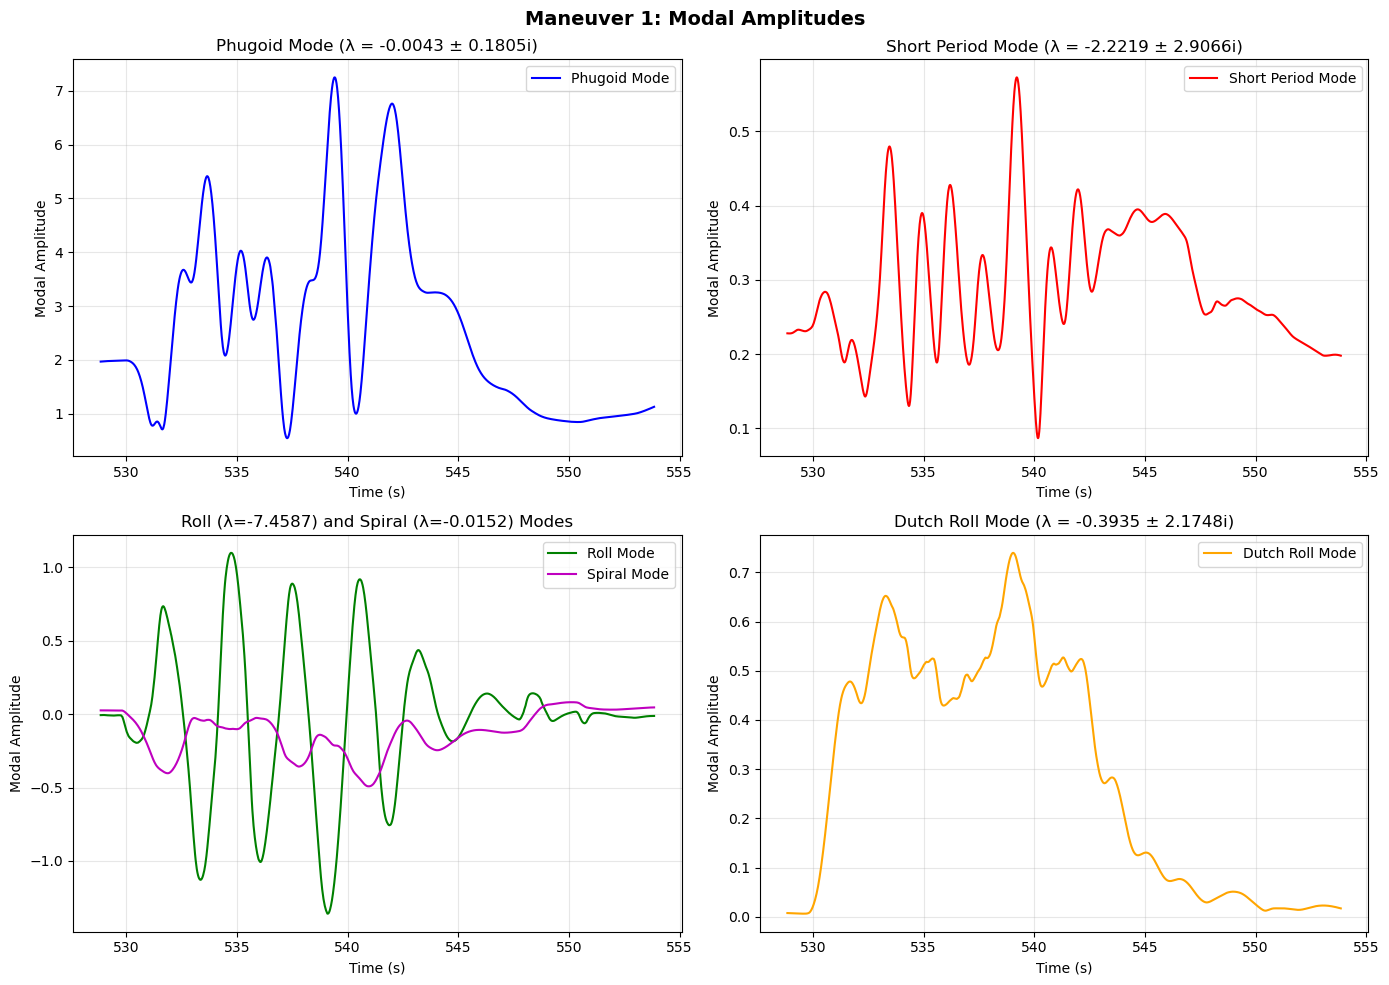

✓ Maneuver 1 modal amplitude plots saved to p4/maneuver1_modal_amplitudes.png


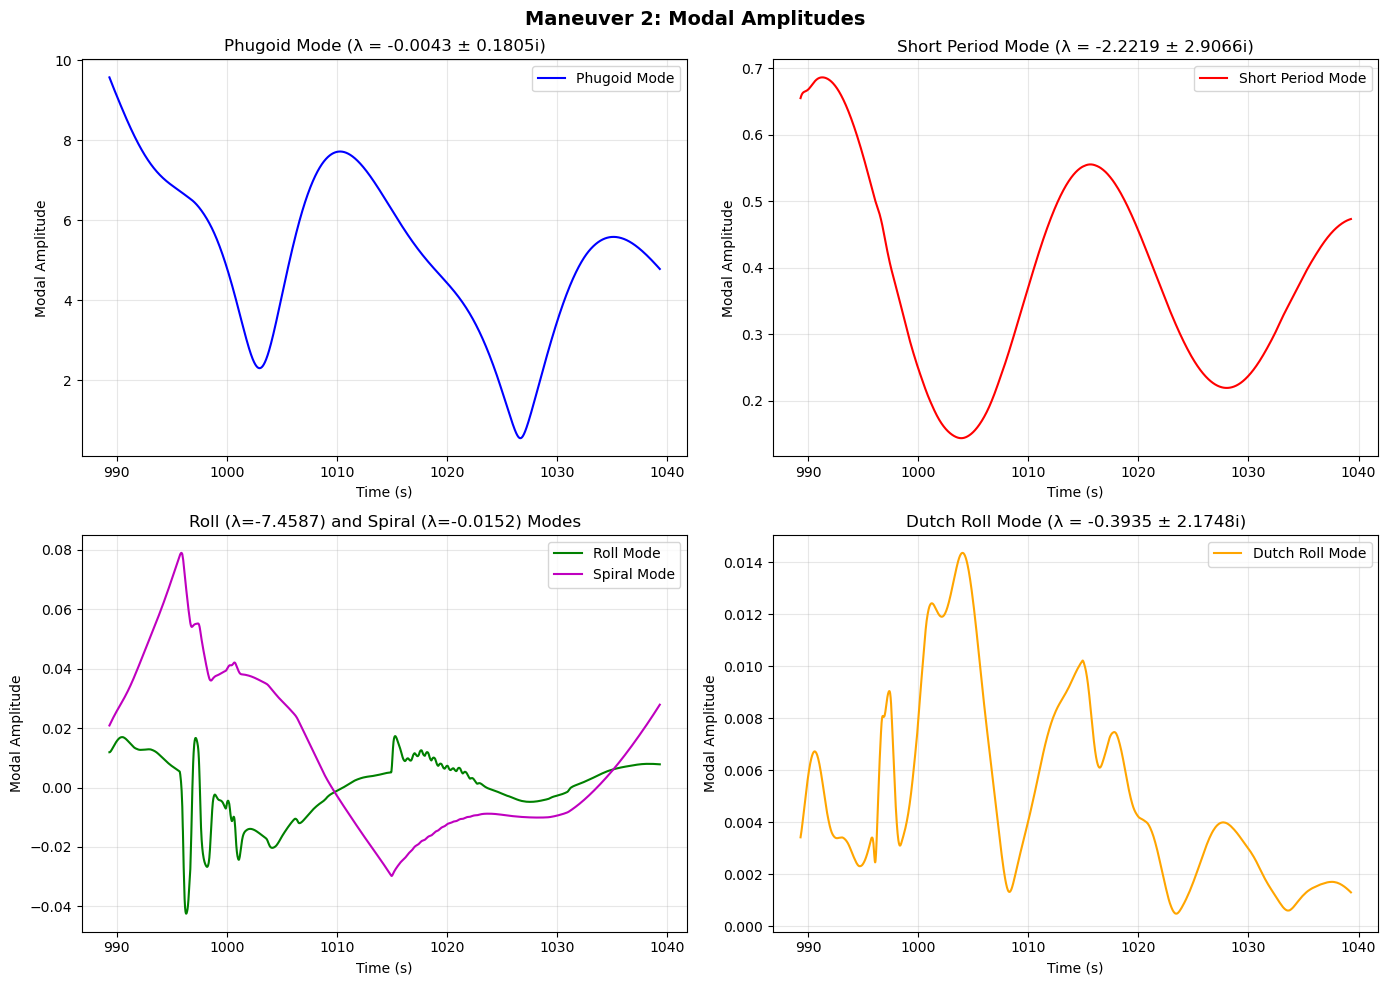

✓ Maneuver 2 modal amplitude plots saved to p4/maneuver2_modal_amplitudes.png

VERIFICATION: Phugoid vs Short Period Modal Amplitudes

Maneuver 1 - Statistics:
  Phugoid Mode amplitude range: [0.547928, 7.247564]
  Phugoid Mode RMS: 3.049949

  Short Period Mode amplitude range: [0.086763, 0.572764]
  Short Period Mode RMS: 0.302085

Maneuver 2 - Statistics:
  Phugoid Mode amplitude range: [0.546740, 9.572961]
  Phugoid Mode RMS: 5.534401

  Short Period Mode amplitude range: [0.143422, 0.686155]
  Short Period Mode RMS: 0.412308

ANALYSIS COMPLETE


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Create output directory
os.makedirs('p4', exist_ok=True)

# Define the longitudinal and lateral matrices 
Alon = np.array([
    [-0.1589, -8.9574, 0.0000, -9.8067],
    [-0.0091, -0.6650, 0.9708, 0.0000],
    [-0.0803, -10.7564, -3.6285, 0.0000],
    [0.0000, 0.0000, 1.0000, 0.0000]
])

Alat = np.array([
    [-0.1011, -0.0014, -0.9919, 0.2118],
    [-11.9041, -7.4078, 1.5131, 0.0000],
    [4.1901, -0.2279, -0.7520, 0.0000],
    [0.0000, 1.0000, 0.0000, 0.0000]
])

# Compute eigenvalues and eigenvectors
eigenvalues_lon, eigenvectors_lon = np.linalg.eig(Alon)
eigenvalues_lat, eigenvectors_lat = np.linalg.eig(Alat)

# Trim state
v_trim = 42.0  # m/s
alpha_trim = 0.0  # rad
q_trim = 0.0  # rad/s
theta_trim = 0.0  # rad
beta_trim = 0.0  # rad
p_trim = 0.0  # rad/s
r_trim = 0.0  # rad/s
phi_trim = 0.0  # rad

def load_and_process_maneuver(filename, maneuver_name):
    """Load CSV data and compute perturbation states"""
    try:
        df = pd.read_csv(filename)
        
        # Convert from degrees to radians where needed
        time = df['Time'].values
        
        # Longitudinal states
        V_abs = df['V_mps'].values  # m/s
        alpha_abs = np.radians(df['alpha_deg'].values)  # rad
        q_abs = np.radians(df['q_degps'].values)  # rad/s
        theta_abs = np.radians(df['pitch_deg'].values)  # rad
        
        # Lateral states
        beta_abs = np.radians(df['beta_deg'].values)  # rad
        p_abs = np.radians(df['p_degps'].values)  # rad/s
        r_abs = np.radians(df['r_degps'].values)  # rad/s
        phi_abs = np.radians(df['roll_deg'].values)  # rad
        
        # Compute perturbation states
        lon_per = np.column_stack([
            V_abs - v_trim,           # δv
            alpha_abs - alpha_trim,   # δα
            q_abs - q_trim,           # δq
            theta_abs - theta_trim    # δθ
        ])
        
        lat_per = np.column_stack([
            beta_abs - beta_trim,     # δβ
            p_abs - p_trim,           # δp
            r_abs - r_trim,           # δr
            phi_abs - phi_trim        # δφ
        ])
        
        # Absolute states
        lon_abs = np.column_stack([V_abs, alpha_abs, q_abs, theta_abs])
        lat_abs = np.column_stack([beta_abs, p_abs, r_abs, phi_abs])
        
        return time, lon_abs, lat_abs, lon_per, lat_per
    
    except FileNotFoundError:
        print(f"Warning: {filename} not found.")
        return None, None, None, None, None

# Load both maneuvers
print("\n" + "=" * 80)
print("LOADING FLIGHT DATA")
print("=" * 80)

t1, lon_abs1, lat_abs1, lon_per1, lat_per1 = load_and_process_maneuver('maneuver_1.csv', 'Maneuver 1')
t2, lon_abs2, lat_abs2, lon_per2, lat_per2 = load_and_process_maneuver('maneuver_2.csv', 'Maneuver 2')

if t1 is not None:
    print(f"Maneuver 1: {len(t1)} data points, time range: {t1[0]:.2f} to {t1[-1]:.2f} seconds")
if t2 is not None:
    print(f"Maneuver 2: {len(t2)} data points, time range: {t2[0]:.2f} to {t2[-1]:.2f} seconds")

# ============================================================================
# MODAL COORDINATE TRANSFORMATION
# ============================================================================

print("\n" + "=" * 80)
print("MODAL COORDINATE TRANSFORMATION")
print("=" * 80)

def transform_to_modal_coordinates(perturbation_states, eigenvectors):
    """Transform perturbation states to modal coordinates: c = V^(-1) * x"""
    if perturbation_states is None:
        return None
    
    n_states = eigenvectors.shape[0]
    V_inv = np.linalg.inv(eigenvectors)
    n_samples = perturbation_states.shape[0]
    modal_coords = np.zeros((n_samples, n_states), dtype=complex)
    
    for i in range(n_samples):
        modal_coords[i, :] = V_inv @ perturbation_states[i, :]
    
    return modal_coords

def get_real_modal_amplitudes(modal_coords, eigenvalues):
    """Extract real modal amplitudes from complex modal coordinates"""
    if modal_coords is None:
        return None
    
    n_states = modal_coords.shape[1]
    n_samples = modal_coords.shape[0]
    real_amplitudes = np.zeros((n_samples, n_states))
    used = [False] * n_states
    
    for i in range(n_states):
        if used[i]:
            continue
            
        if np.abs(eigenvalues[i].imag) > 1e-6:  # Complex eigenvalue
            # Find its conjugate pair
            conj_idx = None
            for j in range(i+1, n_states):
                if np.abs(eigenvalues[i] - np.conj(eigenvalues[j])) < 1e-6:
                    conj_idx = j
                    break
            
            if conj_idx is not None:
                # For complex conjugate pair, use magnitude
                real_amplitudes[:, i] = np.abs(modal_coords[:, i])
                real_amplitudes[:, conj_idx] = np.abs(modal_coords[:, conj_idx])
                used[i] = True
                used[conj_idx] = True
            else:
                real_amplitudes[:, i] = modal_coords[:, i].real
                used[i] = True
        else:  # Real eigenvalue
            real_amplitudes[:, i] = modal_coords[:, i].real
            used[i] = True
    
    return real_amplitudes

# Transform data
print("\nTransforming Maneuver 1 to modal coordinates...")
modal_lon1 = transform_to_modal_coordinates(lon_per1, eigenvectors_lon)
modal_lat1 = transform_to_modal_coordinates(lat_per1, eigenvectors_lat)

real_modal_lon1 = get_real_modal_amplitudes(modal_lon1, eigenvalues_lon)
real_modal_lat1 = get_real_modal_amplitudes(modal_lat1, eigenvalues_lat)

print(f"  Longitudinal modal coordinates shape: {modal_lon1.shape}")
print(f"  Lateral modal coordinates shape: {modal_lat1.shape}")

print("\nTransforming Maneuver 2 to modal coordinates...")
modal_lon2 = transform_to_modal_coordinates(lon_per2, eigenvectors_lon)
modal_lat2 = transform_to_modal_coordinates(lat_per2, eigenvectors_lat)

real_modal_lon2 = get_real_modal_amplitudes(modal_lon2, eigenvalues_lon)
real_modal_lat2 = get_real_modal_amplitudes(modal_lat2, eigenvalues_lat)

print(f"  Longitudinal modal coordinates shape: {modal_lon2.shape}")
print(f"  Lateral modal coordinates shape: {modal_lat2.shape}")

# ============================================================================
# CORRECT MODE IDENTIFICATION
# ============================================================================

print("\n" + "=" * 80)
print("MODE IDENTIFICATION")
print("=" * 80)

# Display eigenvalues with indices for clarity
print("\nLongitudinal Eigenvalues:")
for i, eig in enumerate(eigenvalues_lon):
    print(f"  Index {i}: λ = {eig.real:.6f} + {eig.imag:.6f}j, |λ| = {np.abs(eig):.6f} rad/s")

# Identify Phugoid (slow, low frequency) and Short Period (fast, high frequency)
# For complex pairs, we look at the magnitude
complex_pairs_lon = []
used = [False] * len(eigenvalues_lon)

for i in range(len(eigenvalues_lon)):
    if used[i] or np.abs(eigenvalues_lon[i].imag) < 1e-6:
        continue
    
    # Find conjugate pair
    for j in range(i+1, len(eigenvalues_lon)):
        if np.abs(eigenvalues_lon[i] - np.conj(eigenvalues_lon[j])) < 1e-6:
            complex_pairs_lon.append((i, j, eigenvalues_lon[i]))
            used[i] = used[j] = True
            break

# Sort pairs by magnitude (natural frequency)
complex_pairs_lon.sort(key=lambda x: np.abs(x[2]))

# First pair (smaller magnitude) is Phugoid, second is Short Period
phugoid_pair = complex_pairs_lon[0]
short_period_pair = complex_pairs_lon[1]

phugoid_idx1, phugoid_idx2 = phugoid_pair[0], phugoid_pair[1]
short_period_idx1, short_period_idx2 = short_period_pair[0], short_period_pair[1]

print(f"\nIdentified Modes:")
print(f"  Phugoid Mode: indices {phugoid_idx1} and {phugoid_idx2}")
print(f"    λ = {eigenvalues_lon[phugoid_idx1].real:.6f} ± {eigenvalues_lon[phugoid_idx1].imag:.6f}j")
print(f"    Natural frequency: {np.abs(eigenvalues_lon[phugoid_idx1]):.6f} rad/s")
print(f"\n  Short Period Mode: indices {short_period_idx1} and {short_period_idx2}")
print(f"    λ = {eigenvalues_lon[short_period_idx1].real:.6f} ± {eigenvalues_lon[short_period_idx1].imag:.6f}j")
print(f"    Natural frequency: {np.abs(eigenvalues_lon[short_period_idx1]):.6f} rad/s")

# Lateral mode identification
print("\nLateral Eigenvalues:")
for i, eig in enumerate(eigenvalues_lat):
    print(f"  Index {i}: λ = {eig.real:.6f} + {eig.imag:.6f}j")

# Identify lateral modes
lat_real_indices = [i for i, eig in enumerate(eigenvalues_lat) if np.abs(eig.imag) < 1e-6]
lat_complex_indices = [i for i, eig in enumerate(eigenvalues_lat) if np.abs(eig.imag) > 1e-6]

# Sort real eigenvalues (more negative is Roll, less negative is Spiral)
if len(lat_real_indices) >= 2:
    real_vals = [(i, eigenvalues_lat[i].real) for i in lat_real_indices]
    real_vals.sort(key=lambda x: x[1])  # Sort by real part (more negative first)
    roll_idx = real_vals[0][0]  # Most negative = Roll mode
    spiral_idx = real_vals[1][0]  # Less negative = Spiral mode

# Dutch roll is the complex pair
dutch_idx = lat_complex_indices[0] if len(lat_complex_indices) > 0 else None

print(f"\nIdentified Lateral Modes:")
print(f"  Roll Mode: index {roll_idx}, λ = {eigenvalues_lat[roll_idx].real:.6f}")
print(f"  Spiral Mode: index {spiral_idx}, λ = {eigenvalues_lat[spiral_idx].real:.6f}")
if dutch_idx is not None:
    print(f"  Dutch Roll Mode: index {dutch_idx} and conjugate")
    print(f"    λ = {eigenvalues_lat[dutch_idx].real:.6f} ± {eigenvalues_lat[dutch_idx].imag:.6f}j")

# ============================================================================
# PLOT MODAL AMPLITUDES
# ============================================================================

print("\n" + "=" * 80)
print("GENERATING MODAL AMPLITUDE PLOTS")
print("=" * 80)

if t1 is not None:
    fig1, axes = plt.subplots(2, 2, figsize=(14, 10))
    t_adj1 = t1 #- t1[0]
    
    # Longitudinal modes - use one index from each pair
    axes[0, 0].plot(t_adj1, real_modal_lon1[:, phugoid_idx1], 'b-', linewidth=1.5, label='Phugoid Mode')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Modal Amplitude')
    axes[0, 0].set_title(f'Phugoid Mode (λ = {eigenvalues_lon[phugoid_idx1].real:.4f} ± {eigenvalues_lon[phugoid_idx1].imag:.4f}i)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    axes[0, 1].plot(t_adj1, real_modal_lon1[:, short_period_idx1], 'r-', linewidth=1.5, label='Short Period Mode')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Modal Amplitude')
    axes[0, 1].set_title(f'Short Period Mode (λ = {eigenvalues_lon[short_period_idx1].real:.4f} ± {eigenvalues_lon[short_period_idx1].imag:.4f}i)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Lateral modes
    axes[1, 0].plot(t_adj1, real_modal_lat1[:, roll_idx], 'g-', linewidth=1.5, label='Roll Mode')
    axes[1, 0].plot(t_adj1, real_modal_lat1[:, spiral_idx], 'm-', linewidth=1.5, label='Spiral Mode')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Modal Amplitude')
    axes[1, 0].set_title(f'Roll (λ={eigenvalues_lat[roll_idx].real:.4f}) and Spiral (λ={eigenvalues_lat[spiral_idx].real:.4f}) Modes')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    axes[1, 1].plot(t_adj1, real_modal_lat1[:, dutch_idx], 'orange', linewidth=1.5, label='Dutch Roll Mode')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Modal Amplitude')
    axes[1, 1].set_title(f'Dutch Roll Mode (λ = {eigenvalues_lat[dutch_idx].real:.4f} ± {eigenvalues_lat[dutch_idx].imag:.4f}i)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    
    plt.suptitle('Maneuver 1: Modal Amplitudes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('p4/maneuver1_modal_amplitudes.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Maneuver 1 modal amplitude plots saved to p4/maneuver1_modal_amplitudes.png")

if t2 is not None:
    fig2, axes = plt.subplots(2, 2, figsize=(14, 10))
    t_adj2 = t2 #- t2[0]
    
    # Longitudinal modes
    axes[0, 0].plot(t_adj2, real_modal_lon2[:, phugoid_idx1], 'b-', linewidth=1.5, label='Phugoid Mode')
    axes[0, 0].set_xlabel('Time (s)')
    axes[0, 0].set_ylabel('Modal Amplitude')
    axes[0, 0].set_title(f'Phugoid Mode (λ = {eigenvalues_lon[phugoid_idx1].real:.4f} ± {eigenvalues_lon[phugoid_idx1].imag:.4f}i)')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    axes[0, 1].plot(t_adj2, real_modal_lon2[:, short_period_idx1], 'r-', linewidth=1.5, label='Short Period Mode')
    axes[0, 1].set_xlabel('Time (s)')
    axes[0, 1].set_ylabel('Modal Amplitude')
    axes[0, 1].set_title(f'Short Period Mode (λ = {eigenvalues_lon[short_period_idx1].real:.4f} ± {eigenvalues_lon[short_period_idx1].imag:.4f}i)')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()
    
    # Lateral modes
    axes[1, 0].plot(t_adj2, real_modal_lat2[:, roll_idx], 'g-', linewidth=1.5, label='Roll Mode')
    axes[1, 0].plot(t_adj2, real_modal_lat2[:, spiral_idx], 'm-', linewidth=1.5, label='Spiral Mode')
    axes[1, 0].set_xlabel('Time (s)')
    axes[1, 0].set_ylabel('Modal Amplitude')
    axes[1, 0].set_title(f'Roll (λ={eigenvalues_lat[roll_idx].real:.4f}) and Spiral (λ={eigenvalues_lat[spiral_idx].real:.4f}) Modes')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    axes[1, 1].plot(t_adj2, real_modal_lat2[:, dutch_idx], 'orange', linewidth=1.5, label='Dutch Roll Mode')
    axes[1, 1].set_xlabel('Time (s)')
    axes[1, 1].set_ylabel('Modal Amplitude')
    axes[1, 1].set_title(f'Dutch Roll Mode (λ = {eigenvalues_lat[dutch_idx].real:.4f} ± {eigenvalues_lat[dutch_idx].imag:.4f}i)')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()
    
    plt.suptitle('Maneuver 2: Modal Amplitudes', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('p4/maneuver2_modal_amplitudes.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Maneuver 2 modal amplitude plots saved to p4/maneuver2_modal_amplitudes.png")

# ============================================================================
# VERIFICATION - Check if Phugoid and Short Period are different
# ============================================================================

print("\n" + "=" * 80)
print("VERIFICATION: Phugoid vs Short Period Modal Amplitudes")
print("=" * 80)

if t1 is not None:
    print("\nManeuver 1 - Statistics:")
    print(f"  Phugoid Mode amplitude range: [{real_modal_lon1[:, phugoid_idx1].min():.6f}, {real_modal_lon1[:, phugoid_idx1].max():.6f}]")
    print(f"  Phugoid Mode RMS: {np.sqrt(np.mean(real_modal_lon1[:, phugoid_idx1]**2)):.6f}")
    print(f"\n  Short Period Mode amplitude range: [{real_modal_lon1[:, short_period_idx1].min():.6f}, {real_modal_lon1[:, short_period_idx1].max():.6f}]")
    print(f"  Short Period Mode RMS: {np.sqrt(np.mean(real_modal_lon1[:, short_period_idx1]**2)):.6f}")
    
    # Check if they are correlated (adding debug statement, since was getting the same modes for shot period and phugoid)
    correlation = np.corrcoef(real_modal_lon1[:, phugoid_idx1], real_modal_lon1[:, short_period_idx1])[0, 1]
    # print(f"\n  Correlation between Phugoid and Short Period: {correlation:.6f}")
    # print(f"  {'✓ Different modes (low correlation)' if abs(correlation) < 0.3 else '⚠ Modes may be correlated'}")
if t2 is not None:
    print("\nManeuver 2 - Statistics:")
    print(f"  Phugoid Mode amplitude range: [{real_modal_lon2[:, phugoid_idx2].min():.6f}, {real_modal_lon2[:, phugoid_idx2].max():.6f}]")
    print(f"  Phugoid Mode RMS: {np.sqrt(np.mean(real_modal_lon2[:, phugoid_idx2]**2)):.6f}")
    print(f"\n  Short Period Mode amplitude range: [{real_modal_lon2[:, short_period_idx2].min():.6f}, {real_modal_lon2[:, short_period_idx2].max():.6f}]")
    print(f"  Short Period Mode RMS: {np.sqrt(np.mean(real_modal_lon2[:, short_period_idx2]**2)):.6f}")
    
    # Check if they are correlated (adding debug statement, since was getting the same modes for shot period and phugoid)
    correlation = np.corrcoef(real_modal_lon2[:, phugoid_idx1], real_modal_lon2[:, short_period_idx1])[0, 1]
    # print(f"\n  Correlation between Phugoid and Short Period: {correlation:.6f}")
    #
print("\n" + "=" * 80)
print("ANALYSIS COMPLETE")
print("=" * 80)

Manuever 2 has larger phugoid mode amplitudes (on average, and the peaks) than Manuever 1. The Short-period mode is also more smooth/stronger (on average and at the peaks) in manuever 2. Since both these modes are from the longitudina dynamics, this indicates a stronger excitation of longitudanl dynamics in manuever 2. 
Manuver 1 shows excited lateral-direction modes compared to Manuever 2. In all 3 modes, the dutch roll, roll mode , and spiral mode, the manuever 2 has about 1-2 orders of magnitude higher value (on average + at the peaks) than the manuever 1. So, manever 1 shows strongly excites the lateral dynamics.

Maneuver 1 is dominated by lateral-directional dynamics, so the aircraft motion would primarily consist of rolling and yawing oscillations. The relatively large Dutch roll modal amplitude indicates a pronounced oscillatory motion involving sideslip and yaw, which would appear as a side-to-side shifting of the aircraft. In addition, the strong roll mode contribution suggests rapid changes in bank angle, meaning the plane would exhibit noticeable rolling behavior. The spiral mode is present but weak, so any long-term divergence or convergence in bank angle would be slow and subtle. Overall, this maneuver would look like a combination of oscillatory yawing and rolling with relatively little change in pitch or airspeed.

In contrast, Maneuver 2 is dominated by longitudinal dynamics, so the motion would primarily involve pitching and changes in speed and altitude (opposite to maneuver 1). The large phugoid modal amplitude indicates a long-period oscillation where the aircraft exchanges kinetic and potential energy, resulting in a gentle climb and descent pattern with corresponding variations in airspeed. The short-period mode contributes faster pitch oscillations, but these are relatively well damped and less dominant than the phugoid motion. Because the lateral-directional modal amplitudes are very small, there would be minimal rolling or yawing, and the aircraft would remain nearly wings-level throughout. Overall, this maneuver would appear as a smooth motion characterized by pitch oscillations and gradual altitude changes.